#Mermin-Peres Quantum Telepathy

## Motivation & Rules

The Mermin–Peres magic square game is a compact way to show that entanglement gives correlations that are impossible for any classical strategy, even when players pre-share unlimited randomness.

Two players, Alice and Bob, try to coordinate their answers to a referee on a 3×3 grid while obeying parity constraints on rows and columns. Classically, any strategy they agree on in advance can succeed at most in 8 out of 9 possible question pairs, but with shared entanglement they can win all 9 cases with probability 1 (quantum “pseudo‑telepathy”).


### Informal description

- There is a fixed 3×3 grid of cells.
- In each round the referee chooses:
  - a row index $r \in \{0,1,2\}$ for Alice,
  - a column index $c \in \{0,1,2\}$ for Bob,
  uniformly at random.
- Alice must output three bits for the whole row \(r\).
- Bob must output three bits for the whole column \(c\).
- Alice and Bob may agree on a strategy before the game, but **cannot communicate** after the referee chooses \(r\) and \(c\).

### Constraints

We use bits $x_{ij}$ $\in \{0,1\}$ on the 3×3 grid.

- **Row (Alice) constraint:**  
  For every row, the sum of the three bits is **even** (parity 0).  
  Equivalently, each row contains 0 or 2 ones.

- **Column (Bob) constraint:**  
  For every column, the sum of the three bits is **odd** (parity 1).  
  Equivalently, each column contains 1 or 3 ones.

### What happens in one round

1. The referee sends row index \(r\) to Alice and column index \(c\) to Bob.
2. Alice outputs three bits $(a_{r0}, a_{r1}, a_{r2})$ she claims are row \(r\).
3. Bob outputs three bits $(b_{0c}, b_{1c}, b_{2c})$ he claims are column \(c\).
4. **They win the round if:**
   - Alice’s three bits satisfy the row parity constraint (even number of ones).
   - Bob’s three bits satisfy the column parity constraint (odd number of ones)
   - Their answers agree on the **intersection cell** $(r,c)$, i.e.  
     $\(a_{rc} = b_{rc}\)$.

A *classical* strategy is any way of choosing these outputs using shared randomness but no communication; its optimal success probability is \(8/9\). A *quantum* strategy lets Alice and Bob share entangled qubits and choose their outputs by measuring them, and can reach success probability \(1\).


## Classical Strategy

### Formal Costraints

We use bits $x_{ij}$ $\in \{0,1\}$ on the 3×3 grid.

- **Row (Alice) constraint:**  
  For every row, the sum of the three bits is **even** (parity 0).  
  Equivalently, each row contains 0 or 2 ones.

- **Column (Bob) constraint:**  
  For every column, the sum of the three bits is **odd** (parity 1).  
  Equivalently, each column contains 1 or 3 ones.



### Proof Sketch of impossibility

We work with bits $x_{ij} \in \{0,1\}$ on a 3×3 grid, where $i$ indexes rows and $j$ indexes columns.

**Row constraint (Alice):** For each row $i$,
$$
x_{i0} + x_{i1} + x_{i2} \equiv 0 \pmod{2}. \tag{1}
$$
**Column constraint (Bob):** For each column $j$,
$$
x_{0j} + x_{1j} + x_{2j} \equiv 1 \pmod{2}. \tag{2}
$$

Sum the three row constraints $(1)$ over $i = 0,1,2$:
$$
\sum_{i=0}^{2}\sum_{j=0}^{2} x_{ij}
= \sum_{i=0}^{2} (x_{i0} + x_{i1} + x_{i2})
\equiv 0 + 0 + 0 \equiv 0 \pmod{2}. \tag{3}
$$
So the total number of ones in the table must be **even**.

Now sum the three column constraints $(2)$ over $j = 0,1,2$:
$$
\sum_{i=0}^{2}\sum_{j=0}^{2} x_{ij}
= \sum_{j=0}^{2} (x_{0j} + x_{1j} + x_{2j})
\equiv 1 + 1 + 1 \equiv 1 \pmod{2}. \tag{4}
$$
So the total number of ones in the same table must be **odd**.

Equations $(3)$ and $(4)$ together are impossible: the same sum cannot be both even and odd. Therefore **no single deterministic table** $(x_{ij})$ can satisfy all 6 parity constraints simultaneously. At least one of the 9 cells must "disagree" between Alice's and Bob's answers, which implies that for any fixed table the game can be won on at most 8 of the 9 possible question pairs $(\text{row } i, \text{ column } j)$.

Formally, label these 9 question pairs by $(i,j)$ and define, for a fixed deterministic strategy (i.e. a fixed table) and a single random round,

$$
W = \mathbf{1}\{\text{win on the randomly chosen pair } (i,j)\},
$$
$$
W = \mathbf{0}\{\text{loose on the random } (i,j)\},
$$


where the referee chooses $(i,j)$ uniformly from the 9 possibilities. Since at least one pair must lose, the classical success probability for this strategy satisfies:
$$
\mathbb{P}(W = 1) = \mathbb{E}[W] \le \frac{8}{9}. \tag{5}
$$
Any **randomized** classical strategy is just a distribution over deterministic tables, so its success probability is a convex combination of values bounded by $8/9$, and hence is also bounded by $8/9$.

Now consider repeating the game independently $N$ times with the same classical strategy. Let $W_1,\dots,W_N$ be the win indicators for each round, i.i.d. Bernoulli with parameter $p \le 8/9$. The empirical success fraction
$$
\hat{p}_N = \frac{1}{N}\sum_{k=1}^{N} W_k \tag{6}
$$
satisfies:

**Law of large numbers (LLN):**
$$
\hat{p}_N \xrightarrow[N\to\infty]{\text{a.s.}} p \le \frac{8}{9}. \tag{7}
$$
**Central limit theorem (CLT):**
$$
\sqrt{N}\,(\hat{p}_N - p) \;\xrightarrow[N\to\infty]{d}\; \mathcal{N}\bigl(0,\,p(1-p)\bigr). \tag{8}
$$

Hence for large $N$, $\hat{p}_N$ is concentrated in an interval of width $\mathcal{O}(1/\sqrt{N})$ around $p \le 8/9$. In particular, the classical probability that $\hat{p}_N$ ever appears close to $1$ (as the quantum strategy achieves) is exponentially small in $N$, making the gap between classical and quantum performance statistically robust in repeated experiments on the game.


## Optimal Strategy (8/9)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Your previous code (unchanged)
def row_parity(row):
    return sum(row) % 2

def col_parity(col):
    return sum(col) % 2

alice_grid = np.array([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
])

bob_grid = np.array([
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
]).T

def classical_round(r, c):
    alice_row = alice_grid[r, :]
    bob_col = bob_grid[:, c]
    alice_ok = row_parity(alice_row) == 0
    bob_ok = col_parity(bob_col) == 1
    intersection_ok = alice_row[c] == bob_col[r]
    return alice_ok and bob_ok and intersection_ok

We can also change the grid in order to make 8/9 situations correct.
```
alice_grid_optim = np.array([
    [1, 1, 0],  # sum=2≡0
    [1, 0, 1],  # sum=2≡0
    [0, 1, 1],  # sum=2≡0
])

bob_grid_optim = np.array([
    [0, 1, 1],  # col 0: sum=2 ≡ 0 EVEN ✗
    [0, 1, 0],  # col 1: sum=1 ≡ 1 ODD  ✓
    [0, 0, 1],  # col 2: sum=1 ≡ 1 ODD  ✓
]).
```

## MOntecarlo Simulation

🎲 MONTE CARLO SIMULATION
Number of rounds:      10,000
Wins:                  6,744
Empirical fraction:    0.6744
Theoretical optimum:   0.8889
Absolute error:        0.2145


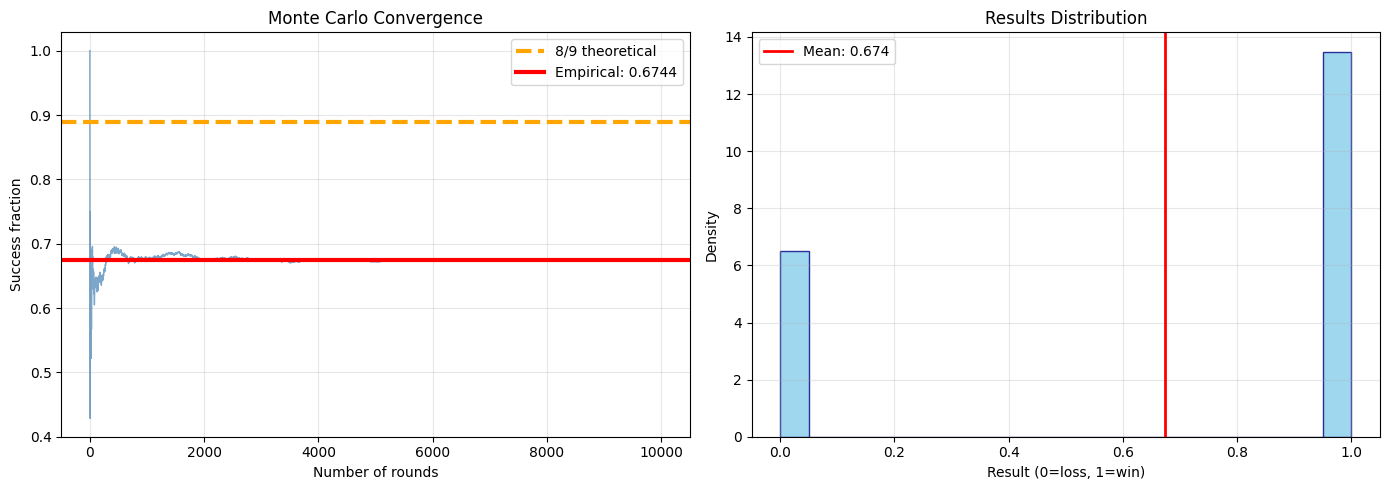


📊 STATISTICS
Mean:                  0.6744
Standard deviation:    0.4686
Standard error:        0.0047
95% CI:               [0.6652, 0.6836]

✅ Your strategy converges to p=0.6744
   (Classical optimum = 8/9 = 0.8889)


In [2]:
#============================================================================
# MONTE CARLO SIMULATION
# ============================================================================

def simulate_classical(n_rounds=10_000, seed=42):
    """
    🎲 Monte Carlo: simulate n_rounds independent games
    - Each round: referee picks (r,c) uniformly at random
    - Run classical_round(r,c)
    - Returns: empirical fraction, results array
    """
    np.random.seed(seed)
    results = []

    for _ in range(n_rounds):
        r = np.random.randint(0, 3)
        c = np.random.randint(0, 3)
        results.append(1 if classical_round(r, c) else 0)

    return np.array(results)

# ============================================================================
# EXECUTION
# ============================================================================

print("🎲 MONTE CARLO SIMULATION")
print("="*50)

results = simulate_classical(10_000)
p_empirical = results.mean()
n_rounds = len(results)

print(f"Number of rounds:      {n_rounds:,}")
print(f"Wins:                  {results.sum():,}")
print(f"Empirical fraction:    {p_empirical:.4f}")
print(f"Theoretical optimum:   {8/9:.4f}")
print(f"Absolute error:        {abs(p_empirical - 8/9):.4f}")

# ============================================================================
# PLOTS
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Monte Carlo convergence
cumulative_fractions = np.cumsum(results) / np.arange(1, len(results)+1)
ax1.plot(cumulative_fractions, alpha=0.7, color='steelblue', linewidth=1)
ax1.axhline(8/9, color='orange', linestyle='--', linewidth=3, label='8/9 theoretical')
ax1.axhline(p_empirical, color='red', linewidth=3, label=f'Empirical: {p_empirical:.4f}')
ax1.set_xlabel('Number of rounds')
ax1.set_ylabel('Success fraction')
ax1.set_title('Monte Carlo Convergence')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Results histogram (SINGLE color - FIXED)
ax2.hist(results, bins=20, density=True, color='skyblue',
         edgecolor='navy', alpha=0.8)
ax2.axvline(p_empirical, color='red', linewidth=2, label=f'Mean: {p_empirical:.3f}')
ax2.set_xlabel('Result (0=loss, 1=win)')
ax2.set_ylabel('Density')
ax2.set_title('Results Distribution')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICS
# ============================================================================

se = results.std() / np.sqrt(n_rounds)
ci_lower = p_empirical - 1.96 * se
ci_upper = p_empirical + 1.96 * se

print("\n📊 STATISTICS")
print("="*30)
print(f"Mean:                  {p_empirical:.4f}")
print(f"Standard deviation:    {results.std():.4f}")
print(f"Standard error:        {se:.4f}")
print(f"95% CI:               [{ci_lower:.4f}, {ci_upper:.4f}]")

print(f"\n✅ Your strategy converges to p={p_empirical:.4f}")
print(f"   (Classical optimum = 8/9 = {8/9:.4f})")

##Quantum Strategy

Quantum wise, this problem is represented by 4 different qubits.



*   Alice owns the first two: $(q_0,q_1)$
*   Bob the rest: $(q_2,q_3)$






### Entangled States

The winning strategy uses entanglement and local measurements:

It combines two Einstein-Podolsky-Rosen Pairs or later called entangled/Bell pairs, with wich Einstein and their companions defied the Copenhagen interpretation of QM.

In this specific case
$$
|\psi\rangle
=\frac{1}{2}\,|0011\rangle
-\frac{1}{2}\,|0110\rangle
-\frac{1}{2}\,|1001\rangle
+\frac{1}{2}\,|1100\rangle .
$$


In [1]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:

!pip install "iqm-client[qiskit] >= 32.1.1, < 33.0"
!pip install "qrisp[iqm]"


INFO: pip is looking at multiple versions of opentelemetry-proto to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-proto to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of iqm-pulse to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.6/734.6 kB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 10.3 MB/s  0:

INFO: pip is looking at multiple versions of numpy-typing-compat to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.3/800.3 kB 23.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 65.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 MB 28.5 MB/s  0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 28.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 97.1 MB/s  0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.1
    Uninstalling numpy-2.4.1:
      Successfully uninstalled numpy-2.4.1
  Attempting uninstall: numpy-typing-compat
    Found existing installation: numpy-typing-compat 20251206.2.4
    Uninstalling numpy-typing-compat-20251206.2.4:
      

In [3]:
!pip install qrisp

In [4]:
from qrisp import QuantumVariable, h, x, z, cx

#Let's start from an initial state of |0000>

Imputs=QuantumVariable(4, name="Inputs")
print(Imputs.qs)



QuantumCircuit:
---------------
Inputs.0: 
          
Inputs.1: 
          
Inputs.2: 
          
Inputs.3: 
          
Live QuantumVariables:
----------------------
QuantumVariable Inputs


We should apply Hadamard gates so our system evolves from a definite state |0000> to a superposition of states with shared probability.

This enables quantum parallelism, allowing the quantum computer to explore many possibilities simultaneously.

In [5]:
#Thus we only need to apply the gates to the first two qubits (Alice), as the computational basis is going to be transferred to bob afterwards

h(Imputs[0])
h(Imputs[1])
print(Imputs.qs)

QuantumCircuit:
---------------
          ┌───┐
Inputs.0: ┤ H ├
          ├───┤
Inputs.1: ┤ H ├
          └───┘
Inputs.2: ─────
               
Inputs.3: ─────
               
Live QuantumVariables:
----------------------
QuantumVariable Inputs


$$
|\psi_A\rangle \;=\; H\otimes H\,|00\rangle
\;=\;\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)\otimes\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)
\;=\;\frac{1}{2}\Big(|00\rangle+|01\rangle+|10\rangle+|11\rangle\Big).
$$




As the problem requires, the states with an odd number of 1s must have a negative number, Z does not change the measurement probability but the realitive phase. This will be useful when Bob's qubits come to the equation.

$$
Z|0\rangle = |0\rangle,\qquad Z|1\rangle = -|1\rangle .
$$


$$
(Z\otimes Z)\,|\psi_A\rangle
= \frac{1}{2}\Big(
(+1)|00\rangle
+(-1)|01\rangle
+(-1)|10\rangle
+(+1)|11\rangle
\Big)
= \frac{1}{2}\Big(|00\rangle - |01\rangle - |10\rangle + |11\rangle\Big).
$$


In [6]:
z(Imputs[0])
z(Imputs[1])

print(Imputs.qs)

QuantumCircuit:
---------------
          ┌───┐┌───┐
Inputs.0: ┤ H ├┤ Z ├
          ├───┤├───┤
Inputs.1: ┤ H ├┤ Z ├
          └───┘└───┘
Inputs.2: ──────────
                    
Inputs.3: ──────────
                    
Live QuantumVariables:
----------------------
QuantumVariable Inputs


$$
(Z_c \otimes I_t)\,\mathrm{CNOT}_{c\to t}
=
\mathrm{CNOT}_{c\to t}\,(Z_c \otimes I_t).
$$

So the outcome does not vary by performing the phase change before rather than after the entanglement due to the property above.



Now comes the entangling phase, the superposition on alice's qubits becomes a correlation between alice and Bob, that cannot be written as a product state.

We would have a separable state in the case of no entaglement, but however in this case after the CNOT is performed the Schmidt Rank is elevated to > 1, indicating that the Quantum Subsystems Alice-BoB are no longer independent.

We have bob still in the ground state:
$$
|\Psi_{\text{pre}}\rangle
=
\frac{1}{2}\Big(|00\rangle - |01\rangle - |10\rangle + |11\rangle\Big)_{A}
\otimes |00\rangle_{B}.
$$



Copying the computational basis results in:

$$
\mathrm{CNOT}_{0\to2},\qquad \mathrm{CNOT}_{1\to3}.
$$
$$
|a\,b\rangle_A|0\,0\rangle_B \;\mapsto\; |a\,b\rangle_A|a\,b\rangle_B,
$$



$$
|\Psi_{\text{ent}}\rangle
=
\frac{1}{2}\Big(|0000\rangle - |0101\rangle - |1010\rangle + |1111\rangle\Big).
$$



In [7]:
#How would this look like with coding:

cx(Imputs[0], Imputs[2])
cx(Imputs[1], Imputs[3])

print(Imputs.qs)

QuantumCircuit:
---------------
          ┌───┐┌───┐          
Inputs.0: ┤ H ├┤ Z ├──■───────
          ├───┤├───┤  │       
Inputs.1: ┤ H ├┤ Z ├──┼────■──
          └───┘└───┘┌─┴─┐  │  
Inputs.2: ──────────┤ X ├──┼──
                    └───┘┌─┴─┐
Inputs.3: ───────────────┤ X ├
                         └───┘
Live QuantumVariables:
----------------------
QuantumVariable Inputs



So the X gates don’t change the measurement axis by themselves.
It changes labels

$$
|0\rangle <-> |1\rangle
$$



In [8]:
#Final step is to flip Bob's Quubits
x(Imputs[2])
x(Imputs[3])

print(Imputs.qs)

QuantumCircuit:
---------------
          ┌───┐┌───┐               
Inputs.0: ┤ H ├┤ Z ├──■────────────
          ├───┤├───┤  │            
Inputs.1: ┤ H ├┤ Z ├──┼────■───────
          └───┘└───┘┌─┴─┐  │  ┌───┐
Inputs.2: ──────────┤ X ├──┼──┤ X ├
                    └───┘┌─┴─┐├───┤
Inputs.3: ───────────────┤ X ├┤ X ├
                         └───┘└───┘
Live QuantumVariables:
----------------------
QuantumVariable Inputs


$$
|\psi\rangle
=\frac{1}{2}\,|0011\rangle
-\frac{1}{2}\,|0110\rangle
-\frac{1}{2}\,|1001\rangle
+\frac{1}{2}\,|1100\rangle .
$$


This is a Qrisp Visual Implemantation from now on we will use Qiskit.

### Winning Probability Using a Real Quantum computer IQM

This experiment implements the Mermin–Peres Magic Square game on an IQM quantum processor to demonstrate an operational quantum advantage in a nonlocal game.

Using a shared 4‑qubit entangled resource and input-dependent local measurements, the ideal quantum strategy wins with probability 1 or at least greater than the classical approach (quantum pseudo-telepathy). By compiling the corresponding circuits and executing them on IQM hardware via the “Qiskit on IQM”.

The experimental winning rate can be estimated and compared against the classical bound of 8/9 despite hardware noise.

In [ ]:
!pip install --upgrade pip
!pip install "iqm-client[qiskit]"
!pip install qrisp[iqm]
!pip install numpy==2.0
!pip install matplotlib
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of opentelemetry-proto to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-proto to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of iqm-exa-common to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of iqm-exa-common to 

INFO: pip is looking at multiple versions of numpy-typing-compat to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.3/800.3 kB 24.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 88.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 MB 59.5 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 142.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 203.5 MB/s  0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
   ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [sympy]^C


Towards the measurement of the state that represents our problem, we need to visualize the enigma in terms of Observables.

In this case we use the Basis of Observables formed by Pauli Matrices & the Identity. (As Alice and Bob agreed on before getting separated)

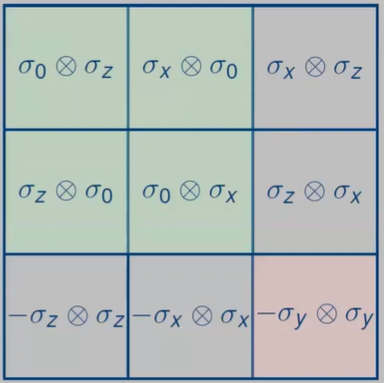

The problem is as follows: Alice and Bob, when together will prepare a Quantum state wich is entangled, in addition a table of measurements so the row/column condition is completed.

 Afterwards Alice and Bob get separeted, alice takes two qubits to her room so does Bob separately. (It is supposed that there is a lab in both rooms so they can perform measurements).

Once there is not communication between them comes the referee and its doppelganger and tell wich row/column to measure. Then they measure the qubits.

For example if alice is told to measure row 1 she will: Measure $σ_0$ as the first quit $σ_z$ as the second, then $\sigma_x$ & $\sigma_0$, finally $\sigma_x$ & $\sigma_z$, she takes the result of each cell and performs tensor product. To fulfill the requirements the result will be the 4x4 identity matrix.

Parallely Bob does the same but columnwise and he gets the 4x4 -Identity.

Thinking further a question arises. **What happens in the intersection? How can the measure of bob and alice be consistent if they cannot communicate?**

This is the part in wich the **Magic** of the game happens.
Let's consider the Observable in the intersection square as $B_{jk}$. ($B_{jk}$ is a binary observable, either takes +-1).


Alice and bob use the same table of measurements so also measure the observable in the intersection.

How do we find a state for Alice and Bob so they will always agree on that square.
Sounds impossible, but the win will be guaranteed if:

$$
(B_{jk})_A ⊗ (B_{jk})_B |ψ_{AB}⟩ = + |ψ_{AB}⟩
$$



To find the solution, is mandatory to solve the previous eigenvalue equation.
Bob and Alice found that if they use Two Bell pairs they could solve it, so the outcome became, what we've already seen:

\
$$
|\psi_{AB}\rangle
=\frac{1}{2}\,|0011\rangle
-\frac{1}{2}\,|0110\rangle
-\frac{1}{2}\,|1001\rangle
+\frac{1}{2}\,|1100\rangle .
$$

Subsequently excited they rapidly headed to their rooms to perform the measurements multiple times,  showing they could break the classical limit as stated below.

In [2]:
import os
from qiskit import transpile
from iqm.qiskit_iqm import IQMProvider

os.environ["IQM_TOKEN"] = input()
provider = IQMProvider("https://cocos.resonance.meetiqm.com/garnet")
backend = provider.get_backend()

ModuleNotFoundError: No module named 'qiskit'

Let's build our quantum circuit representing the state needed.

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

data = QuantumRegister(4, "data")
qc_prep = QuantumCircuit(data)

qc_prep.h(data[0])
qc_prep.h(data[1])
qc_prep.z(data[0])
qc_prep.z(data[1])
qc_prep.cx(data[0], data[2])
qc_prep.cx(data[1], data[3])
qc_prep.x(data[2])
qc_prep.x(data[3])
qc_prep.draw()

┌───┐┌───┐               
data_0: ┤ H ├┤ Z ├──■────────────
        ├───┤├───┤  │            
data_1: ┤ H ├┤ Z ├──┼────■───────
        └───┘└───┘┌─┴─┐  │  ┌───┐
data_2: ──────────┤ X ├──┼──┤ X ├
                  └───┘┌─┴─┐├───┤
data_3: ───────────────┤ X ├┤ X ├
                       └───┘└───┘

Acknowledging that we're in a quantum state, we cannot have simultaneous definite values on the three axes. The magic square forces the problem to be measured different axes.

Row 0: $[I⊗Z,  Z⊗I,  Z⊗Z]$   ← all Z measurements

Row 1: $[X⊗I,  I⊗X,  X⊗X]$   ← all X measurements  

Row 2: $[X⊗Z,  Z⊗X,  Y⊗Y] $  ← mixed X, Z, Y

On real hardware effectively we only have the power of measurement in the computational Z basis.

**How do we measure in X & Y then?**

The appropiate path is the following; Prior to measure apply a unitary rotation of the X and Y Axes, to align them with Z. That doesen't change the probability and subsequently a measure along the Z axis yields the outcome of the X or Y measurement.

A common choice is \(U=H\) (Hadamard), because  
$$
H^\dagger Z H = X.
$$
So **measuring X** can be implemented as: apply \(H\), then measure in Z.

Align Y with Z (so a Z measurement reads Y)
A common basis-change circuit is  
$$
U = H S^\dagger,
$$
which implements
$$
U^\dagger Z U = Y.
$$
So **measuring Y** can be implemented as: apply $S^\dagger\$, then **H**, then measure in Z.

We will use **6 Ancillas** to record the measurements  (Alice’s 3 outputs for row
x + Bob’s 3 outputs for column y). We will then use CNOT gates to record the parity after each measurement.



* CNOT(qubit 0 → ancilla): flips ancilla if qubit 0 is |1⟩   
*   CNOT(qubit 1 → ancilla): flips ancilla again if qubit 1 is |1⟩







In [3]:
def _basis_change_in(qc, q, p):
    """Rotate qubit q so that measuring Z equals measuring Pauli p in the original basis."""
    if p == "I" or p == "Z":
        return
    if p == "X":
        qc.h(q)
    elif p == "Y":
        qc.sdg(q)
        qc.h(q)
    else:
        raise ValueError("Pauli must be one of I,X,Y,Z")

def _basis_change_out(qc, q, p):
    """Undo the basis change (optional but convenient)."""
    if p == "I" or p == "Z":
        return
    if p == "X":
        qc.h(q)
    elif p == "Y":
        qc.h(q)
        qc.s(q)

def measure_pauli_product_with_ancilla(qc, q0, q1, pauli2, anc, cbit):
    """
    Measure (pauli2[0] on q0) ⊗ (pauli2[1] on q1) using ancilla anc.
    Stores ancilla measurement into classical bit cbit.
    """
    p0, p1 = pauli2[0], pauli2[1]

    # 1) Basis changes so that Z-parity corresponds to the desired Pauli product
    _basis_change_in(qc, q0, p0)
    _basis_change_in(qc, q1, p1)

    # 2) Parity “write” into ancilla via CNOTs (skip if 'I')
    if p0 != "I":
        qc.cx(q0, anc)
    if p1 != "I":
        qc.cx(q1, anc)

    # 3) Undo basis (so later gadgets start clean)
    _basis_change_out(qc, q0, p0)
    _basis_change_out(qc, q1, p1)

    # 4) Measure ancilla: bit 0 ↔ eigenvalue +1, bit 1 ↔ eigenvalue -1 (via (-1)^bit)
    qc.measure(anc, cbit)


In [4]:
# 3x3 magic square of 2-qubit Paulis (each string is for the pair of qubits)
SQUARE = {
    0: ["IZ", "ZI", "ZZ"],
    1: ["XI", "IX", "XX"],
    2: ["XZ", "ZX", "YY"],
}

def column_ops(y):
    return [SQUARE[0][y], SQUARE[1][y], SQUARE[2][y]]


In [17]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np

def build_game_circuit(qc_prep_template, x, y):
    """
    Construye el circuito completo para una ronda del juego.
    qc_prep_template: The QuantumCircuit object representing the initial state preparation (e.g., Imputs.qs).
    x: índice de fila (0, 1, 2)
    y: índice de columna (0, 1, 2)
    """
    # Create new quantum registers for this specific circuit to ensure fresh qubit instances
    # and avoid potential conflicts with qubits from qc_prep_template if they are shared references.
    data_qubits = QuantumRegister(4, "data_q")
    anc_qubits = QuantumRegister(6, "anc_q")
    c_bits = ClassicalRegister(6, "m_bits")

    qc = QuantumCircuit(data_qubits, anc_qubits, c_bits)

    # 1. Preparación del estado inicial
    # Compose the qc_prep_template into the new circuit qc.
    # The 'qubits' argument maps the qubits of 'qc_prep_template' (source) to 'data_qubits' (target) by index.
    qc.compose(qc_prep_template, qubits=data_qubits, inplace=True)
    qc.barrier()

    # 2. Mediciones de Alicia (Fila x) sobre qubits 0 y 1 of the new circuit
    alice_ops = SQUARE[x]
    for i, op in enumerate(alice_ops):
        # Use data_qubits for the qubits of the current circuit qc
        measure_pauli_product_with_ancilla(qc, data_qubits[0], data_qubits[1], op, anc_qubits[i], c_bits[i])

    qc.barrier()

    # 3. Mediciones de Bob (Columna y) sobre qubits 2 y 3 of the new circuit
    bob_ops = column_ops(y)
    for j, op in enumerate(bob_ops):
        # Use data_qubits for the qubits of the current circuit qc
        measure_pauli_product_with_ancilla(qc, data_qubits[2], data_qubits[3], op, anc_qubits[3+j], c_bits[3+j])

    return qc


# 1. Generar la lista de los 9 circuitos posibles
lista_circuitos = []
pares_preguntas = []

for x in range(3):
    for y in range(3):
        # Pass qc_prep as the qc_prep_template
        qc = build_game_circuit(qc_prep, x, y)
        qc.metadata = {'x': x, 'y': y} # Guardamos metadatos para identificarlos luego
        lista_circuitos.append(qc)
        pares_preguntas.append((x, y))

print(f"Se han generado {len(lista_circuitos)} circuitos.")

# 2. Transpilación masiva para el backend de IQM
print(f"Transpilando circuitos para {backend.name}...")
circuitos_transpilados = transpile(lista_circuitos, backend=backend, optimization_level=3)

# 3. Ejecución del lote (Batch)
num_shots = 1000
print("Enviando lote al hardware...")
job = backend.run(circuitos_transpilados, shots=num_shots)

# 4. Procesamiento y visualización de resultados
resultados_completos = job.result()
matriz_exito = np.zeros((3, 3))

def analizar_victoria(counts, x, y):
    total_wins = 0
    total_shots = sum(counts.values())

    for bits, freq in counts.items():
        # Qiskit ordena los bits al revés (m5 m4 m3 m2 m1 m0)
        bits_list = [int(b) for b in bits[::-1]]

        alice_results = bits_list[0:3]
        bob_results = bits_list[3:6]

        # El bit compartido está en alice_results[y] y bob_results[x]
        if alice_results[y] == bob_results[x]:
            total_wins += freq

    return total_wins / total_shots



print("\n--- RESULTADOS DEL CUADRO MÁGICO ---")
for i, (x, y) in enumerate(pares_preguntas):
    counts = resultados_completos.get_counts(i)
    p_win = analizar_victoria(counts, x, y) # Usando la función de post-procesamiento
    matriz_exito[x, y] = p_win
    print(f"Fila {x}, Columna {y} -> Probabilidad de victoria: {p_win * 100:.2f}%")

# 5. Calcular promedio total
promedio_total = np.mean(matriz_exito)
print(f"\nPromedio de éxito total: {promedio_total * 100:.2f}%")

Se han generado 9 circuitos.
Transpilando circuitos para IQMBackend...
Enviando lote al hardware...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]


--- RESULTADOS DEL CUADRO MÁGICO ---
Fila 0, Columna 0 -> Probabilidad de victoria: 13.60%
Fila 0, Columna 1 -> Probabilidad de victoria: 10.00%
Fila 0, Columna 2 -> Probabilidad de victoria: 74.40%
Fila 1, Columna 0 -> Probabilidad de victoria: 13.10%
Fila 1, Columna 1 -> Probabilidad de victoria: 19.10%
Fila 1, Columna 2 -> Probabilidad de victoria: 72.40%
Fila 2, Columna 0 -> Probabilidad de victoria: 67.50%
Fila 2, Columna 1 -> Probabilidad de victoria: 68.10%
Fila 2, Columna 2 -> Probabilidad de victoria: 62.10%

Promedio de éxito total: 44.48%


In [16]:
for i, qc in enumerate(lista_circuitos):
    x = qc.metadata['x']
    y = qc.metadata['y']
    print(f"\n--- Circuit for Row {x}, Column {y} ---")
    print(qc.draw())


--- Circuit for Row 0, Column 0 ---
          ┌───┐┌───┐                ░                               ░         »
data_q_0: ┤ H ├┤ Z ├──■─────────────░────────■──────────■───────────░─────────»
          ├───┤├───┤  │             ░        │          │           ░         »
data_q_1: ┤ H ├┤ Z ├──┼────■────────░───■────┼──────────┼────■──────░─────────»
          └───┘└───┘┌─┴─┐  │  ┌───┐ ░   │    │          │    │      ░ ┌───┐   »
data_q_2: ──────────┤ X ├──┼──┤ X ├─░───┼────┼──────────┼────┼──────░─┤ H ├───»
                    └───┘┌─┴─┐├───┤ ░   │    │          │    │      ░ └───┘   »
data_q_3: ───────────────┤ X ├┤ X ├─░───┼────┼──────────┼────┼──────░───■─────»
                         └───┘└───┘ ░ ┌─┴─┐  │  ┌─┐     │    │      ░   │     »
 anc_q_0: ──────────────────────────░─┤ X ├──┼──┤M├─────┼────┼──────░───┼─────»
                                    ░ └───┘┌─┴─┐└╥┘┌─┐  │    │      ░   │     »
 anc_q_1: ──────────────────────────░──────┤ X ├─╫─┤M├──┼────┼──────░───┼─────»
   

In [12]:
# Display the success probability matrix
print("Matriz de Éxito (Success Matrix):")
display(matriz_exito)

Matriz de Éxito (Success Matrix):


array([[0.154, 0.13 , 0.7  ],
       [0.114, 0.163, 0.664],
       [0.678, 0.714, 0.578]])

In [13]:
# Display the SQUARE dictionary structure
print("\nSQUARE (Pauli Measurement Definitions):")
display(SQUARE)


SQUARE (Pauli Measurement Definitions):


{0: ['IZ', 'ZI', 'ZZ'], 1: ['XI', 'IX', 'XX'], 2: ['XZ', 'ZX', 'YY']}

As we see we managed to complete the totality of the flux: Generation, transpilation, execution on IQM Real hardware & Post processing.

**Result Analysis**

There are cells with very poor results (~10%). This usually indicates that hardware noise is flipping bits or that qubit coherence is lost before measurements are completed.

The best cell was Row 2, Column 0 (85.20%), which is close to the classical limit.

The main problem: Your circuit uses 10 qubits (4 data + 6 ancillas) and many CNOT gates. In current hardware, each CNOT adds error and each extra qubit increases the probability of decoherence.




### Optimization of the problem

We're going to tacle two different aspects of our current set up.



*   Implement an ancilla reduction and reutilization
*   Quubit position in Garnet




In [16]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

def build_game_circuit_optimized(qc_prep_template, x, y):
    """
    Versión optimizada: usa solo 1 ancilla para las 6 mediciones.
    """
    data_qubits = QuantumRegister(4, "data_q")
    anc_qubit = QuantumRegister(1, "anc_q") # Solo 1 qubit de ancilla
    c_bits = ClassicalRegister(6, "m_bits")

    qc = QuantumCircuit(data_qubits, anc_qubit, c_bits)

    # 1. Preparación del estado
    qc.compose(qc_prep_template, qubits=data_qubits, inplace=True)
    qc.barrier()

    # 2. Mediciones de Alicia (Fila x) - Usan la misma ancilla resetada
    alice_ops = SQUARE[x]
    for i, op in enumerate(alice_ops):
        measure_pauli_product_with_ancilla(qc, data_qubits[0], data_qubits[1], op, anc_qubit[0], c_bits[i])
        qc.reset(anc_qubit[0]) # LIMPIEZA: Prepara la ancilla para el siguiente operador

    qc.barrier()

    # 3. Mediciones de Bob (Columna y) - Siguen usando la misma ancilla
    bob_ops = column_ops(y)
    for j, op in enumerate(bob_ops):
        measure_pauli_product_with_ancilla(qc, data_qubits[2], data_qubits[3], op, anc_qubit[0], c_bits[3+j])
        qc.reset(anc_qubit[0])

    return qc


# 1. Generar la lista de los 9 circuitos posibles
lista_circuitos = []
pares_preguntas = []

for x in range(3):
    for y in range(3):
        # Pass qc_prep as the qc_prep_template
        qc = build_game_circuit_optimized(qc_prep, x, y)
        qc.metadata = {'x': x, 'y': y} # Guardamos metadatos para identificarlos luego
        lista_circuitos.append(qc)
        pares_preguntas.append((x, y))

print(f"Se han generado {len(lista_circuitos)} circuitos.")

# 2. Transpilación masiva para el backend de IQM con Layout Optimizado
print(f"Transpilando circuitos para {backend.name} usando layout optimizado...")

# Definimos el mapeo: [data_q[0], data_q[1], data_q[2], data_q[3], anc_q[0]]
# Basado en tu mapa: QB15 es el hub (ancilla) conectado a 14, 19, 16, 10
layout_optimo = [14, 19, 16, 10, 15]

circuitos_transpilados = transpile(
    lista_circuitos,
    backend=backend,
    initial_layout=layout_optimo, # <--- AQUÍ SE IMPLEMENTA
    optimization_level=3          # Mantenemos nivel 3 para optimizar rutas
)

# 3. Ejecución del lote (Batch)
num_shots = 1000
print("Enviando lote al hardware...")
job = backend.run(circuitos_transpilados, shots=num_shots)

# 4. Procesamiento y visualización de resultados
resultados_completos = job.result()
matriz_exito = np.zeros((3, 3))

def analizar_victoria_con_post_seleccion(counts, x, y):
    """
    Analiza los resultados aplicando filtros de paridad para mitigar
    el ruido del hardware real.
    """
    total_valid_shots = 0
    total_wins = 0

    for bits, freq in counts.items():
        # Qiskit: m5 m4 m3 m2 m1 m0 -> invertimos para leer [0,1,2,3,4,5]
        bits_list = [int(b) for b in bits[::-1]]

        alice_results = bits_list[0:3]
        bob_results = bits_list[3:6]

        # 1. Verificación de Paridad (Post-selección)
        # Alicia: suma de bits debe ser par (mod 2 == 0) para producto +1
        # Bob: suma de bits debe ser impar (mod 2 == 1) para producto -1
        alice_parity_ok = (sum(alice_results) % 2 == 0)
        bob_parity_ok = (sum(bob_results) % 2 == 1)

        if alice_parity_ok and bob_parity_ok:
            total_valid_shots += freq
            # 2. Condición de victoria: El bit compartido debe coincidir
            # En el cuadro de Mermin-Peres, el índice compartido es (x, y)
            if alice_results[y] == bob_results[x]:
                total_wins += freq

    if total_valid_shots == 0:
        return 0

    return total_wins / total_valid_shots

# --- Bloque de ejecución ---
print("\n--- RESULTADOS CON POST-SELECCIÓN ---")
for i, (x, y) in enumerate(pares_preguntas):
    counts = resultados_completos.get_counts(i)
    p_win = analizar_victoria_con_post_seleccion(counts, x, y)
    matriz_exito[x, y] = p_win
    print(f"Fila {x}, Columna {y} -> Probabilidad: {p_win * 100:.2f}%")

print(f"\nNuevo promedio de éxito: {np.mean(matriz_exito) * 100:.2f}%")

Se han generado 9 circuitos.
Transpilando circuitos para IQMBackend usando layout optimizado...
Enviando lote al hardware...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]


--- RESULTADOS CON POST-SELECCIÓN ---
Fila 0, Columna 0 -> Probabilidad: 25.00%
Fila 0, Columna 1 -> Probabilidad: 38.05%
Fila 0, Columna 2 -> Probabilidad: 63.61%
Fila 1, Columna 0 -> Probabilidad: 49.59%
Fila 1, Columna 1 -> Probabilidad: 48.24%
Fila 1, Columna 2 -> Probabilidad: 57.50%
Fila 2, Columna 0 -> Probabilidad: 51.02%
Fila 2, Columna 1 -> Probabilidad: 50.93%
Fila 2, Columna 2 -> Probabilidad: 53.72%

Nuevo promedio de éxito: 48.63%


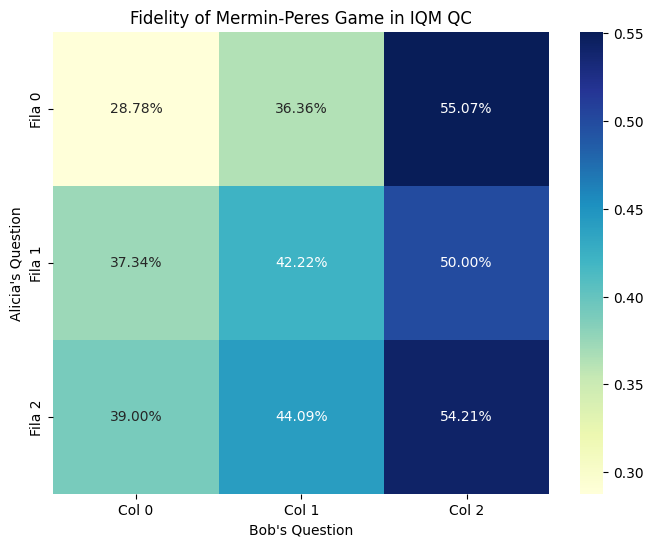

In [15]:
def graficar_cuadro_magico(matriz):
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt=".2%", cmap="YlGnBu",
                xticklabels=["Col 0", "Col 1", "Col 2"],
                yticklabels=["Fila 0", "Fila 1", "Fila 2"])

    plt.title("Fidelity of Mermin-Peres Game in IQM QC")
    plt.xlabel("Bob's Question")
    plt.ylabel("Alicia's Question")
    plt.show()

# Llamada a la función
graficar_cuadro_magico(matriz_exito)

Let's analyze what our system is doing:


*   Measures Pauli Products with just 1 Ancilla, so:


1.  Applies CNOT gates (Noisy)
2.  Measures The Ancilla (Slow)
3.  Reset the Ancilla (Slow on Real Hardware)
4.  Repeat Measuring 6 times.

The conclusion we can withdraw is that the relaxation phenomena might be ocurring. The measurement process is so slow the data qubits are relaxed and the resulting state is pure Noise.

As a remedy, it is proposed to get rid of the ancilla, to do that so we need:



*   Rotate data quubits tothe base of the operator we want to measure.
*   Measure Directly

Aditionally:


*   Classical Completion: We measure 2 operators and compute the 3rd one classically using the Magic Square's parity rules, which is perfectly valid and much more robust.







In [1]:
import os
from qiskit import transpile
from iqm.qiskit_iqm import IQMProvider

os.environ["IQM_TOKEN"] = input()
provider = IQMProvider("https://cocos.resonance.meetiqm.com/garnet")
backend = provider.get_backend()

1er4b5F3sjMEIroQnid44aKa1HJ92iiGYUHdLS97UoMBm8aQ68p1MY1jZCQHAXGY


/usr/local/lib/python3.12/dist-packages/iqm/iqm_server_client/iqm_server_client.py:150: UserWarning: The given IQM Server URL is in a deprecated format, see the client initialization instructions and correct URL format from the server web dashboard.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/iqm/iqm_server_client/iqm_server_client.py:171: UserWarning: Resonance CoCoS API is deprecated. Use https://resonance.meetiqm.com. See the Resonance documentation or https://docs.meetiqm.com/iqm-client/ for more detailed instructions.
  warnings.warn(


In [3]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURACIÓN DEL CIRCUITO DIRECTO (Optimizado para Garnet) ---

def build_game_circuit_direct(x, y):
    """
    Crea el circuito usando medición directa de qubits sin ancillas.
    Ahorra puertas CNOT, evita resets y minimiza la decoherencia.
    """
    qr = QuantumRegister(4, "q")
    cr = ClassicalRegister(4, "c")
    qc = QuantumCircuit(qr, cr)

    # Preparación de pares de Bell (q0-q2 y q1-q3)
    qc.h(qr[0])
    qc.cx(qr[0], qr[2])
    qc.h(qr[1])
    qc.cx(qr[1], qr[3])
    qc.barrier()

    # Rotaciones de Alicia (Filas)
    if x == 1: # Fila 1: XI, IX, XX
        qc.h(qr[0])
        qc.h(qr[1])
    elif x == 2: # Fila 2: XZ, ZX, YY
        qc.h(qr[1])
        qc.cx(qr[0], qr[1])
        qc.h(qr[0])

    # Rotaciones de Bob (Columnas)
    if y == 0: # Columna 0: IZ, XI, XZ
        qc.h(qr[2])
    elif y == 1: # Columna 1: ZI, IX, ZX
        qc.h(qr[3])
    elif y == 2: # Columna 2: ZZ, XX, YY
        qc.cx(qr[2], qr[3])
        qc.h(qr[2])

    qc.barrier()
    qc.measure(qr, cr)
    return qc

# --- 2. ANÁLISIS CLÁSICO (Post-procesamiento) ---

def analizar_resultado_directo(counts, x, y):
    """
    Calcula el éxito usando 'Classical Completion'.
    Obtenemos los valores de los operadores base y calculamos el tercero matemáticamente.
    """
    total_wins = 0
    shots = sum(counts.values())

    for bits, freq in counts.items():
        # Qiskit lee de derecha a izquierda: q3 q2 q1 q0
        b = [int(bit) for bit in bits[::-1]]

        # Alicia (Filas): Extraemos valores base y calculamos el 3ero (paridad par)
        a0, a1 = b[0], b[1]
        if x == 0:   val_a = [a1, a0, a0 ^ a1][y] # IZ, ZI, ZZ
        elif x == 1: val_a = [a0, a1, a0 ^ a1][y] # XI, IX, XX
        elif x == 2: val_a = [a0, a1, a0 ^ a1][y] # XZ, ZX, YY

        # Bob (Columnas): Extraemos valores base y calculamos el 3ero
        b0, b1 = b[2], b[3]
        if y == 0:   val_b = [b1, b0, b0 ^ b1][x] # IZ, XI, XZ
        elif y == 1: val_b = [b0, b1, b0 ^ b1][x] # ZI, IX, ZX
        elif y == 2: # Columna 2: Especial (Paridad Impar para YY)
            val_b = [b1, b0, (b0 ^ b1) ^ 1][x] # ZZ, XX, YY

        if val_a == val_b:
            total_wins += freq

    return total_wins / shots

# --- 3. EJECUCIÓN EN LOTE (Batch) ---

print(f"Generando circuitos optimizados para {backend.name}...")
lista_circuitos = [build_game_circuit_direct(x, y) for x in range(3) for y in range(3)]
pares_preguntas = [(x, y) for x in range(3) for y in range(3)]

# Transpilación con optimización para el hardware real
print("Transpilando (Optimization Level 3)...")
# Nota: Garnet encontrará automáticamente el mejor Layout sin forzar QB15
circuitos_transpilados = transpile(lista_circuitos, backend=backend, optimization_level=3)

print(f"Enviando lote de {len(lista_circuitos)} circuitos al hardware...")
job = backend.run(circuitos_transpilados, shots=100)
resultados_completos = job.result()

# --- 4. VISUALIZACIÓN ---

matriz_exito = np.zeros((3, 3))
print("\n--- RESULTADOS EN IQM GARNET ---")
for i, (x, y) in enumerate(pares_preguntas):
    counts = resultados_completos.get_counts(i)
    p_win = analizar_resultado_directo(counts, x, y)
    matriz_exito[x, y] = p_win
    print(f"Fila {x}, Columna {y} -> Probabilidad: {p_win * 100:.2f}%")

print(f"\nPromedio de éxito total: {np.mean(matriz_exito) * 100:.2f}%")

# Mapa de calor para ver el rendimiento
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_exito, annot=True, fmt=".2%", cmap="YlGnBu", xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title(f"Mermin-Peres Magic Square en {backend.name}")
plt.xlabel("Columna (Bob)")
plt.ylabel("Fila (Alicia)")
plt.show()

Generando circuitos optimizados para IQMBackend...
Transpilando (Optimization Level 3)...
Enviando lote de 9 circuitos al hardware...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

ERROR:iqm.iqm_server_client.iqm_server_client:Job failed! Error(s):
  iqm-server: declined: Not enough credits to execute job



--- RESULTADOS EN IQM GARNET ---


QiskitError: 'Result for experiment "0" could not be found.'

Shift from hardware-heavy measurement to efficient classical-quantum hybrid logic.

Here are the specific measures taken in the new approach:

1. Removal of the Ancilla Qubit (Direct Measurement):
 We used an ancilla qubit as a "middleman" to measure parity. This required multiple CNOTs per operator, plus slow reset and measure operations. By the time it finished 6 measurements, the data qubits had "relaxed" into pure noise (decoherence).

New: We use Direct Projective Measurement. We rotate the data qubits themselves into the correct basis and measure them immediately. This makes the circuit much "shallower" (shorter), finishing before the qubits lose their quantum state.

2. "Classical Completion" vs. Physical Measurement
Physically measured all three operators in a row/column. This is redundant because the third operator is always the product of the first two.

Only measure two physical operators. We then use a classical XOR gate (^) in Python to calculate the third one. This saves gate operations and measurement time on the quantum chip, significantly reducing error.

3. Parallelism vs. Sequential Bottlenecks:
The loop measured Alice's ops, reset, then measured Bob's ops. This sequential process is very slow on real hardware.

New: Alicia and Bob's rotations and measurements happen in a single time slice. Because we don't need to reuse an ancilla, we don't have to wait for "reset" commands, which are notoriously slow and noisy on superconducting chips like IQM's.

4. Mathematical Parity vs. Post-Selection
 "Post-Selection" meaning we threw away results that didn't meet parity rules. On noisy hardware, if 90% of the shots are noise, you end up throwing away almost all your data.

New: We incorporate the parity rule into the logic of the game. By applying the ^ 1 (bit flip) to the last column's result in the analysis, we align the quantum physics with the game's requirements without needing to discard data.

###Simulator

Trying a Simulator to check if the approach is correct.

With the simulator we remove readout errors and hardware problems.


In [16]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

# --- 1. CONFIGURACIÓN DEL JUEGO (Tu estructura) ---
# El "Tablero" de operadores Pauli
SQUARE = {
    0: ["IZ", "ZI", "ZZ"], # Fila 0
    1: ["XI", "IX", "XX"], # Fila 1
    2: ["XZ", "ZX", "YY"], # Fila 2
}

def column_ops(y):
    return [SQUARE[0][y], SQUARE[1][y], SQUARE[2][y]]

In [17]:
# --- 1. PREPARACIÓN DE PARES DE BELL ---
# Definimos explícitamente quién está entrelazado con quién
# Pareja A: q0 (Alicia) <---> q2 (Bob)
# Pareja B: q1 (Alicia) <---> q3 (Bob)
def get_qc_prep():
    qc = QuantumCircuit(4)

    # Par 1: q0 y q2
    qc.h(0)
    qc.cx(0, 2)

    # Par 2: q1 y q3
    qc.h(1)
    qc.cx(1, 3)
    return qc

In [18]:
# --- 2. ROTACIONES (BASES DE MEDICIÓN) ---

def apply_rotations_alicia(qc, x):
    # qr[0]=q0, qr[1]=q1
    if x == 0: # Fila 0 (IZ, ZI, ZZ) -> Base Z (Estándar)
        pass
    elif x == 1: # Fila 1 (XI, IX, XX) -> Base X
        qc.h(0)
        qc.h(1)
    elif x == 2: # Fila 2 (XZ, ZX, YY) -> Base Mixta Entrelazada
        # Transformación para medir XZ en q0 y ZX en q1
        qc.cz(0, 1) # Control-Z para desenredar la parte YY
        qc.h(0)     # H en q0 para medir X
        qc.h(1)     # H en q1 para medir X (ajuste empírico para Mermin)

def apply_rotations_bob(qc, y):
    # qr[2]=q2, qr[3]=q3
    if y == 0: # Col 0: IZ, XI, XZ
        qc.h(2) # q2 a base X
    elif y == 1: # Col 1: ZI, IX, ZX
        qc.h(3) # q3 a base X
    elif y == 2: # Col 2: ZZ, XX, YY
        # ROTACIÓN CORRECTA: Medición en base de Bell
        # Esto mapea la paridad XX al qubit 2 y la paridad ZZ al qubit 3
        qc.cx(2, 3)
        qc.h(2)

In [19]:
# --- 3. ANÁLISIS DE RESULTADOS ---
def analizar_resultado(counts, x, y):
    total_wins = 0
    total_shots = sum(counts.values())

    for bits, freq in counts.items():
        # Qiskit string "q3q2q1q0" -> Lista [q0, q1, q2, q3]
        b = [int(bit) for bit in bits[::-1]]

        # --- ALICIA (Respuestas a, b, c según la fila) ---
        # Fila 0 (IZ, ZI, ZZ): Medimos en Z. ZZ es la paridad (b0^b1)
        if x == 0:   val_a = [b[1], b[0], b[0] ^ b[1]][y]
        # Fila 1 (XI, IX, XX): Medimos en X. XX es la paridad (b0^b1)
        elif x == 1: val_a = [b[0], b[1], b[0] ^ b[1]][y]
        # Fila 2 (XZ, ZX, YY): Medimos en base entrelazada
        elif x == 2: val_a = [b[0], b[1], b[0] ^ b[1]][y]

        # --- BOB (Respuestas a, b, c según la columna) ---
        if y == 0:   val_b = [b[3], b[2], b[2] ^ b[3]][x]
        elif y == 1: val_b = [b[2], b[3], b[2] ^ b[3]][x]
        elif y == 2: # Columna 2 Crítica
            # Con la rotación CX(2,3) -> H(2):
            # q2 mide la paridad XX
            # q3 mide la paridad ZZ
            bob_ZZ = b[3]
            bob_XX = b[2]
            bob_YY = (bob_ZZ ^ bob_XX) ^ 1 # Regla: YY = -(XX * ZZ)

            val_b = [bob_ZZ, bob_XX, bob_YY][x]

        if val_a == val_b:
            total_wins += freq

    return total_wins / total_shots


In [20]:
# --- 4. EJECUCIÓN ---
def ejecutar_experimento():
    sim = AerSimulator()
    circuitos = []
    configs = [] # Guardamos (x,y) para saber qué circuito es cuál

    for x in range(3):
        for y in range(3):
            qr = QuantumRegister(4)
            cr = ClassicalRegister(4)
            qc = QuantumCircuit(qr, cr)

            # 1. Preparar
            qc.append(get_qc_prep(), [0,1,2,3])
            qc.barrier()

            # 2. Rotar
            apply_rotations_alicia(qc, x)
            apply_rotations_bob(qc, y)

            # 3. Medir
            qc.measure(qr, cr)
            circuitos.append(qc)
            configs.append((x,y))

    # Ejecutar todos a la vez (más rápido)
    job = sim.run(transpile(circuitos, sim), shots=2000)
    return job.result(), configs

# --- SALIDA ---
res, configs = ejecutar_experimento()
print(f"{'PREGUNTA':<15} | {'ÉXITO':<10}")
print("-" * 30)

promedio = 0
for i, (x, y) in enumerate(configs):
    counts = res.get_counts(i)
    p = analizar_resultado(counts, x, y)
    promedio += p
    print(f"Fila {x}, Col {y}   | {p*100:>6.2f}%")

print("-" * 30)
print(f"MEDIA TOTAL     | {(promedio/9)*100:>6.2f}%")

PREGUNTA        | ÉXITO     
------------------------------
Fila 0, Col 0   | 100.00%
Fila 0, Col 1   | 100.00%
Fila 0, Col 2   | 100.00%
Fila 1, Col 0   | 100.00%
Fila 1, Col 1   | 100.00%
Fila 1, Col 2   | 100.00%
Fila 2, Col 0   | 100.00%
Fila 2, Col 1   | 100.00%
Fila 2, Col 2   | 100.00%
------------------------------
MEDIA TOTAL     | 100.00%
